In [4]:
import requests
import csv

URL = "https://archive-api.open-meteo.com/v1/archive"
PARAMS = {
    "latitude": -15.50082,
    "longitude": -70.13980,
    "start_date": "2010-01-01",
    "end_date": "2026-09-08",
    "hourly": "temperature_2m,precipitation,relative_humidity_2m,cloud_cover,wind_speed_10m,surface_pressure",
    "timezone": "America/Lima",
}
SALIDA = "data/clima_juliaca_horario.csv"

respuesta = requests.get(URL, params=PARAMS)
respuesta.raise_for_status()
datos = respuesta.json()["hourly"]

columnas = list(datos.keys())
filas = zip(*[datos[c] for c in columnas])

with open(SALIDA, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(columnas)
    writer.writerows(filas)

print(f"Guardado: {SALIDA} ({len(datos['time'])} filas)")

Guardado: data/clima_juliaca_horario.csv (146280 filas)


# U1 - Heladas y Lluvia: Monitoreo y anticipación de riesgo climático en Juliaca

**Equipo:** BIG IMPACT · **Integrante:** Nilver Salcca Aquino
**Dimensión:** Heladas — predictiva, batch (U1)

## 1.1 Crear el notebook y la SparkSession

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("bigdata-u1-heladas")
    .master("local[*]")
    .config("spark.ui.port", "4040")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/09 12:23:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/09 12:23:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## 1.2 Definir el esquema y cargar los datos

In [5]:
from pyspark.sql.types import StructType, StructField, TimestampType, DoubleType

ORIGEN_DATOS = "/opt/bigdata-u1/data"

schema_clima = StructType([
    StructField("time", TimestampType(), nullable=False),
    StructField("temperature_2m", DoubleType(), nullable=True),
    StructField("precipitation", DoubleType(), nullable=True),
    StructField("relative_humidity_2m", DoubleType(), nullable=True),
    StructField("cloud_cover", DoubleType(), nullable=True),
    StructField("wind_speed_10m", DoubleType(), nullable=True),
    StructField("surface_pressure", DoubleType(), nullable=True),
])

df = (
    spark.read
    .option("timestampFormat", "yyyy-MM-dd'T'HH:mm")
    .csv(f"{ORIGEN_DATOS}/clima_juliaca_horario.csv", header=True, schema=schema_clima)
)

df.printSchema()
df.show(5)
print(f"Total filas: {df.count():,}")

root
 |-- time: timestamp (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- relative_humidity_2m: double (nullable = true)
 |-- cloud_cover: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- surface_pressure: double (nullable = true)

+-------------------+--------------+-------------+--------------------+-----------+--------------+----------------+
|               time|temperature_2m|precipitation|relative_humidity_2m|cloud_cover|wind_speed_10m|surface_pressure|
+-------------------+--------------+-------------+--------------------+-----------+--------------+----------------+
|2010-01-01 00:00:00|           6.8|          0.0|                84.0|       93.0|           4.9|           645.3|
|2010-01-01 01:00:00|           5.5|          0.0|                91.0|       89.0|           6.2|           643.7|
|2010-01-01 02:00:00|           5.5|          0.0|                83.0|       91.0|           6

## 1.3 Verificar rango de temperatura en todo el periodo

In [6]:
df.select("temperature_2m").describe().show()

+-------+------------------+
|summary|    temperature_2m|
+-------+------------------+
|  count|            146280|
|   mean| 8.414492070002648|
| stddev|4.7313542721283515|
|    min|              -7.4|
|    max|              22.4|
+-------+------------------+



## 2.1 Verificar nulos en todas las columnas

In [7]:
from pyspark.sql.functions import col, count as spark_count, when

df.select([
    spark_count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show(vertical=True, truncate=False)

[Stage 14:=============================>                            (1 + 1) / 2]

-RECORD 0-------------------
 time                 | 0   
 temperature_2m       | 0   
 precipitation        | 0   
 relative_humidity_2m | 0   
 cloud_cover          | 0   
 wind_speed_10m       | 0   
 surface_pressure     | 0   



## 2.2 Gráfico de verificación de nulos

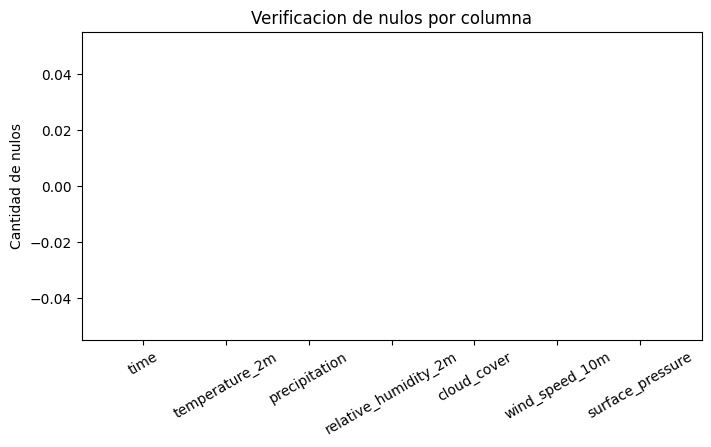

In [35]:
nulos_dict = {c: df.filter(col(c).isNull()).count() for c in df.columns}

plt.figure(figsize=(8, 4))
plt.bar(nulos_dict.keys(), nulos_dict.values(), color="firebrick")
plt.ylabel("Cantidad de nulos")
plt.title("Verificacion de nulos por columna")
plt.xticks(rotation=30)
plt.show()

## 3.1 Agregar a valores diarios

In [8]:
from pyspark.sql.functions import to_date, min as spark_min, avg

df_diario = (
    df
    .withColumn("fecha", to_date(col("time")))
    .groupBy("fecha")
    .agg(
        spark_min("temperature_2m").alias("temp_min_dia"),
        avg("relative_humidity_2m").alias("humedad_prom_dia"),
        avg("cloud_cover").alias("nubosidad_prom_dia"),
        avg("surface_pressure").alias("presion_prom_dia"),
    )
)

df_diario.orderBy("fecha").show(5)
print(f"Total dias: {df_diario.count():,}")

+----------+------------+-----------------+------------------+-----------------+
|     fecha|temp_min_dia| humedad_prom_dia|nubosidad_prom_dia| presion_prom_dia|
+----------+------------+-----------------+------------------+-----------------+
|2010-01-01|         4.5|65.29166666666667| 83.95833333333333|645.9083333333333|
|2010-01-02|         5.6|75.54166666666667| 83.45833333333333|          645.525|
|2010-01-03|         6.7|73.79166666666667|             99.25|646.1166666666667|
|2010-01-04|         6.0|79.33333333333333|             99.25|646.1625000000001|
|2010-01-05|         6.1|77.79166666666667|            90.125|            647.1|
+----------+------------+-----------------+------------------+-----------------+
only showing top 5 rows
Total dias: 6,095


## 3.2 Evidencia del plan de ejecución (lazy evaluation)

In [15]:
df_diario.explain(True)

== Parsed Logical Plan ==
'Project [unresolvedstarwithcolumns(dia_cos, 'cos('`*`('dia_anio, 0.01721420632103996)), None)]
+- Project [fecha#337, temp_min_dia#338, humedad_prom_dia#339, nubosidad_prom_dia#340, presion_prom_dia#341, hay_helada#413, dia_anio#414, SIN((cast(dia_anio#414 as double) * 0.01721420632103996)) AS dia_sin#415]
   +- Project [fecha#337, temp_min_dia#338, humedad_prom_dia#339, nubosidad_prom_dia#340, presion_prom_dia#341, hay_helada#413, dayofyear(fecha#337) AS dia_anio#414]
      +- Project [fecha#337, temp_min_dia#338, humedad_prom_dia#339, nubosidad_prom_dia#340, presion_prom_dia#341, CASE WHEN (temp_min_dia#338 < 0.0) THEN 1.0 ELSE 0.0 END AS hay_helada#413]
         +- Aggregate [fecha#337], [fecha#337, min(temperature_2m#134) AS temp_min_dia#338, avg(relative_humidity_2m#136) AS humedad_prom_dia#339, avg(cloud_cover#137) AS nubosidad_prom_dia#340, avg(surface_pressure#139) AS presion_prom_dia#341]
            +- Project [time#133, temperature_2m#134, precipit

## 3.3 Verificar duplicados

In [16]:
total = df_diario.count()
sin_duplicar = df_diario.dropDuplicates(["fecha"]).count()

print(f"Total: {total:,}, sin duplicar por fecha: {sin_duplicar:,}")
assert total == sin_duplicar, "Hay fechas duplicadas en la agregacion diaria"

Total: 6,095, sin duplicar por fecha: 6,095


## 3.4 Escribir salida Gold en Parquet, particionada por año

In [17]:
from pyspark.sql.functions import year

RUTA_GOLD = "/opt/bigdata-u1/artifacts/heladas_gold"

df_diario_particionable = df_diario.withColumn("anio", year(col("fecha")))

(
    df_diario_particionable
    .repartition(4)
    .write.format("parquet")
    .mode("overwrite")
    .partitionBy("anio")
    .save(RUTA_GOLD)
)

import os
print("Carpetas de particion creadas:")
for carpeta in sorted(os.listdir(RUTA_GOLD)):
    print(" -", carpeta)

Carpetas de particion creadas:
 - ._SUCCESS.crc
 - _SUCCESS
 - anio=2010
 - anio=2011
 - anio=2012
 - anio=2013
 - anio=2014
 - anio=2015
 - anio=2016
 - anio=2017
 - anio=2018
 - anio=2019
 - anio=2020
 - anio=2021
 - anio=2022
 - anio=2023
 - anio=2024
 - anio=2025
 - anio=2026


## 3.5 Verificar lectura de vuelta y PartitionFilters

In [18]:
df_gold = spark.read.parquet(RUTA_GOLD)

total_original = df_diario_particionable.count()
total_leido = df_gold.count()
print(f"Filas escritas: {total_original:,}, filas leidas de vuelta: {total_leido:,}")
assert total_original == total_leido, "Se perdieron filas al escribir/leer el Parquet"

df_gold.filter(col("anio") == 2022).explain()

Filas escritas: 6,095, filas leidas de vuelta: 6,095
== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [fecha#1558,temp_min_dia#1559,humedad_prom_dia#1560,nubosidad_prom_dia#1561,presion_prom_dia#1562,hay_helada#1563,dia_anio#1564,dia_sin#1565,dia_cos#1566,anio#1567] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/opt/bigdata-u1/artifacts/heladas_gold], PartitionFilters: [isnotnull(anio#1567), (anio#1567 = 2022)], PushedFilters: [], ReadSchema: struct<fecha:date,temp_min_dia:double,humedad_prom_dia:double,nubosidad_prom_dia:double,presion_p...




## 4.1 Marcar heladas y codificar el día del año (cíclico)

In [9]:
from pyspark.sql.functions import when, dayofyear, sin, cos, lit
import math

UMBRAL_HELADA = 0.0

df_diario = (
    df_diario
    .withColumn("hay_helada", when(col("temp_min_dia") < UMBRAL_HELADA, 1.0).otherwise(0.0))
    .withColumn("dia_anio", dayofyear(col("fecha")))
    .withColumn("dia_sin", sin(col("dia_anio") * (2 * math.pi / 365)))
    .withColumn("dia_cos", cos(col("dia_anio") * (2 * math.pi / 365)))
)

df_diario.select("fecha", "temp_min_dia", "hay_helada", "dia_anio", "dia_sin", "dia_cos").show(5)

+----------+------------+----------+--------+------------------+------------------+
|     fecha|temp_min_dia|hay_helada|dia_anio|           dia_sin|           dia_cos|
+----------+------------+----------+--------+------------------+------------------+
|2010-01-15|         3.3|       0.0|      15| 0.255353295116187|0.9668478136052775|
|2010-01-16|         6.2|       0.0|      16|0.2719581575341055|0.9623090774541486|
|2010-01-30|         4.6|       0.0|      30|0.4937755501599772| 0.869589389346611|
|2010-01-31|         5.1|       0.0|      31|0.5086709438521044|0.8609610158889943|
|2010-02-11|         4.0|       0.0|      42|0.6616346182422783|0.7498264012045686|
+----------+------------+----------+--------+------------------+------------------+
only showing top 5 rows


## 4.2 Resumen mensual y gráfico de tendencia

In [27]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 3.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 4.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 4.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 4.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


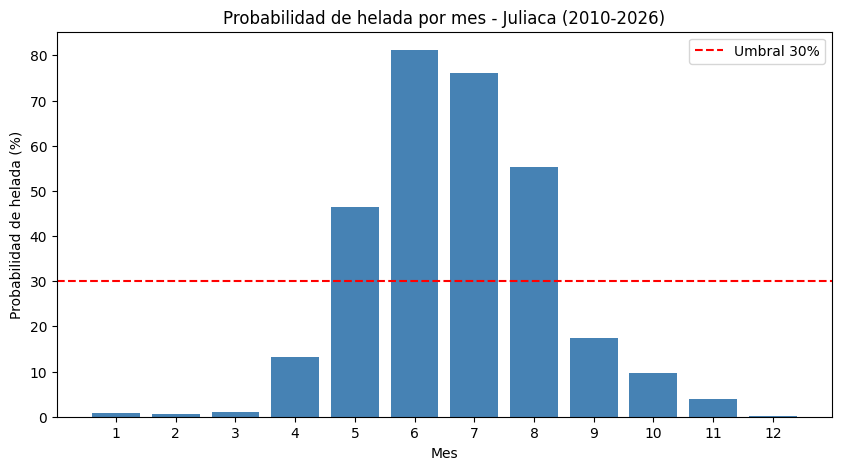

In [28]:
from pyspark.sql.functions import month
import matplotlib.pyplot as plt

resumen_mensual = (
    df_diario
    .withColumn("mes", month(col("fecha")))
    .groupBy("mes")
    .agg(avg("hay_helada").alias("prob_helada"))
    .orderBy("mes")
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.bar(resumen_mensual["mes"], resumen_mensual["prob_helada"] * 100, color="steelblue")
plt.axhline(y=30, color="red", linestyle="--", label="Umbral 30%")
plt.xlabel("Mes")
plt.ylabel("Probabilidad de helada (%)")
plt.title("Probabilidad de helada por mes - Juliaca (2010-2026)")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

## 4.3 Distribución de temperatura mínima por mes (boxplot)

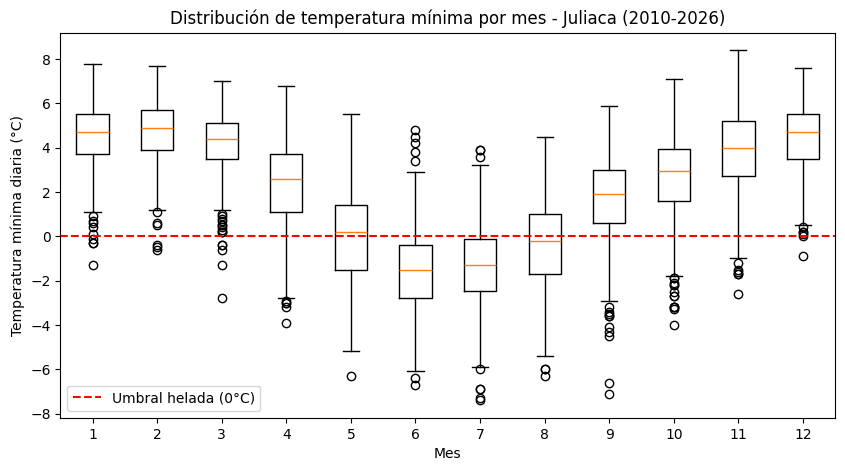

In [33]:
datos_boxplot = (
    df_diario
    .withColumn("mes", month(col("fecha")))
    .select("mes", "temp_min_dia")
    .toPandas()
)

grupos = [datos_boxplot[datos_boxplot["mes"] == m]["temp_min_dia"].values for m in range(1, 13)]

plt.figure(figsize=(10, 5))
plt.boxplot(grupos, tick_labels=range(1, 13))
plt.axhline(y=0, color="red", linestyle="--", label="Umbral helada (0°C)")
plt.xlabel("Mes")
plt.ylabel("Temperatura mínima diaria (°C)")
plt.title("Distribución de temperatura mínima por mes - Juliaca (2010-2026)")
plt.legend()
plt.show()

## 4.4 Correlación de cada variable con la helada

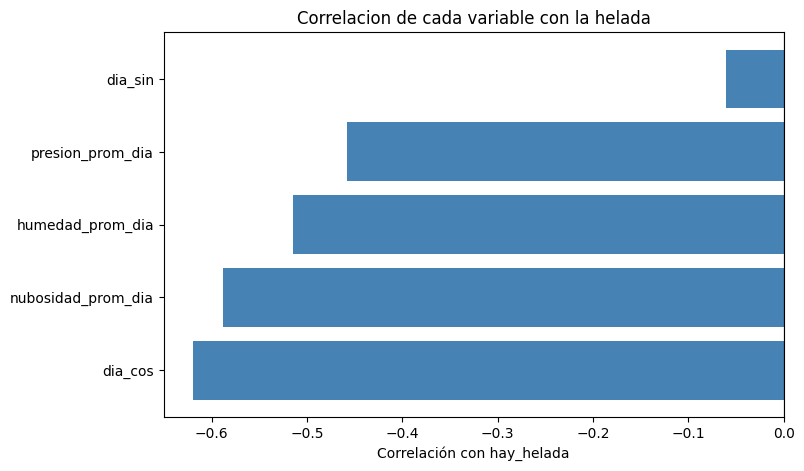

In [34]:
predictores_candidatos = ["dia_sin", "dia_cos", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia"]

correlaciones = {
    p: df_diario.stat.corr(p, "hay_helada")
    for p in predictores_candidatos
}

df_corr = pd.DataFrame(list(correlaciones.items()), columns=["variable", "correlacion"]).sort_values("correlacion")

plt.figure(figsize=(8, 5))
plt.barh(df_corr["variable"], df_corr["correlacion"], color="steelblue")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Correlación con hay_helada")
plt.title("Correlacion de cada variable con la helada")
plt.show()

## 4.5 Matriz de correlación completa

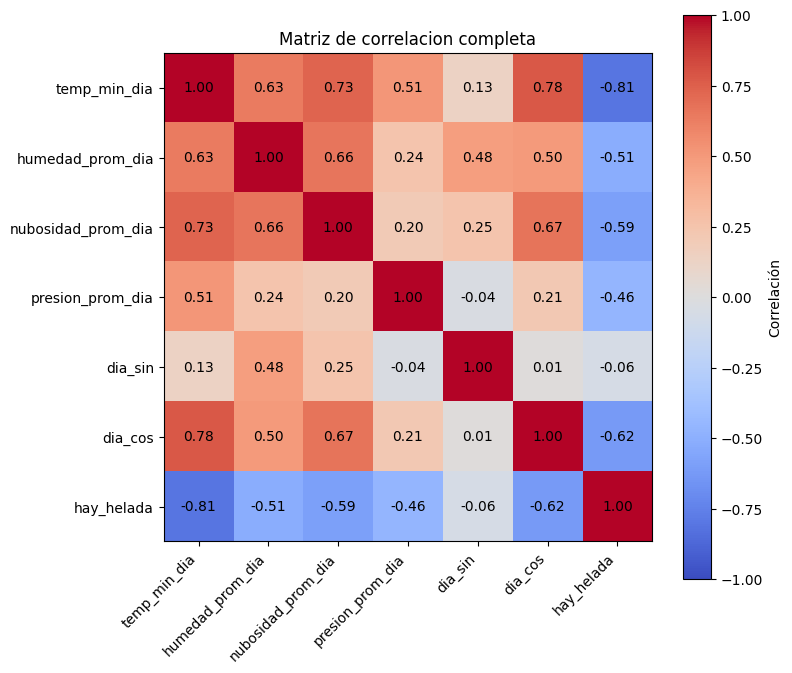

In [36]:
import numpy as np

variables_matriz = ["temp_min_dia", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia", "dia_sin", "dia_cos", "hay_helada"]

matriz = np.zeros((len(variables_matriz), len(variables_matriz)))
for i, v1 in enumerate(variables_matriz):
    for j, v2 in enumerate(variables_matriz):
        matriz[i, j] = df_diario.stat.corr(v1, v2)

plt.figure(figsize=(8, 7))
plt.imshow(matriz, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(variables_matriz)), variables_matriz, rotation=45, ha="right")
plt.yticks(range(len(variables_matriz)), variables_matriz)
for i in range(len(variables_matriz)):
    for j in range(len(variables_matriz)):
        plt.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Matriz de correlacion completa")
plt.tight_layout()
plt.show()

## 5. Vectores de predictores (dos configuraciones) y división train/test

In [22]:
from pyspark.ml.feature import VectorAssembler

# Config A: solo estacionalidad (dia del año)
assembler_simple = VectorAssembler(
    inputCols=["dia_sin", "dia_cos"],
    outputCol="features_simple"
)

# Config B: estacionalidad + contexto meteorologico (humedad, nubosidad, presion)
assembler_enriquecido = VectorAssembler(
    inputCols=["dia_sin", "dia_cos", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia"],
    outputCol="features_enriquecido"
)

df_features = assembler_simple.transform(df_gold)
df_features = assembler_enriquecido.transform(df_features)

df_train, df_test = df_features.randomSplit([0.8, 0.2], seed=42)

print(f"Filas train: {df_train.count():,}")
print(f"Filas test: {df_test.count():,}")

Filas train: 4,892


[Stage 318:====>                                                  (1 + 11) / 12]

Filas test: 1,203


## 6. Entrenar y evaluar Config A (solo estacionalidad)

In [23]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

log_simple = LogisticRegression(featuresCol="features_simple", labelCol="hay_helada")
modelo_log_simple = log_simple.fit(df_train)

predicciones_log_simple = modelo_log_simple.transform(df_test)

evaluador_auc = BinaryClassificationEvaluator(labelCol="hay_helada", metricName="areaUnderROC")
evaluador_f1 = MulticlassClassificationEvaluator(labelCol="hay_helada", predictionCol="prediction", metricName="f1")

auc_simple = evaluador_auc.evaluate(predicciones_log_simple)
f1_simple = evaluador_f1.evaluate(predicciones_log_simple)

print(f"Config A (solo dia del anio) -> AUC: {auc_simple:.4f}, F1: {f1_simple:.4f}")

Config A (solo dia del anio) -> AUC: 0.9101, F1: 0.8555


## 7. Entrenar y evaluar Config B (estacionalidad + contexto meteorológico)

In [24]:
log_enriquecido = LogisticRegression(featuresCol="features_enriquecido", labelCol="hay_helada")
modelo_log_enriquecido = log_enriquecido.fit(df_train)

predicciones_log_enriquecido = modelo_log_enriquecido.transform(df_test)

auc_enriquecido = evaluador_auc.evaluate(predicciones_log_enriquecido)
f1_enriquecido = evaluador_f1.evaluate(predicciones_log_enriquecido)

print(f"Config B (dia + humedad + nubosidad + presion) -> AUC: {auc_enriquecido:.4f}, F1: {f1_enriquecido:.4f}")

Config B (dia + humedad + nubosidad + presion) -> AUC: 0.9640, F1: 0.9109


## 8.1 Interpretar el modelo ganador: importancia de cada variable

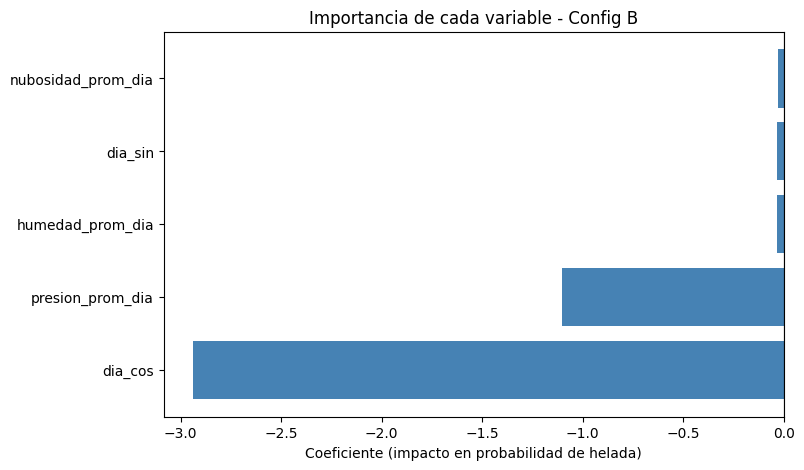

In [29]:
import pandas as pd

variables = ["dia_sin", "dia_cos", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia"]
coeficientes = modelo_log_enriquecido.coefficients.toArray()

df_coef = pd.DataFrame({"variable": variables, "coeficiente": coeficientes}).sort_values("coeficiente")

plt.figure(figsize=(8, 5))
plt.barh(df_coef["variable"], df_coef["coeficiente"], color="steelblue")
plt.xlabel("Coeficiente (impacto en probabilidad de helada)")
plt.title("Importancia de cada variable - Config B")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.show()

## 8.2 Curva ROC del modelo ganador

In [31]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 3.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 4.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


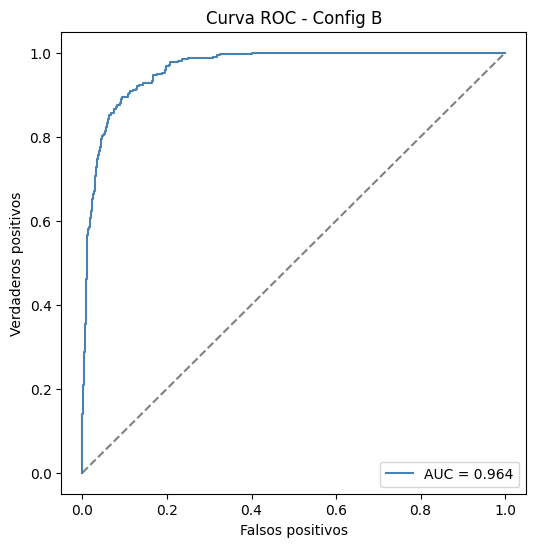

In [32]:
from sklearn.metrics import roc_curve

pred_pandas = predicciones_log_enriquecido.select("hay_helada", "probability").toPandas()
pred_pandas["prob_helada"] = pred_pandas["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(pred_pandas["hay_helada"], pred_pandas["prob_helada"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc_enriquecido:.3f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC - Config B")
plt.legend()
plt.show()

## 8.3 Matriz de confusión - Config A (comparación)

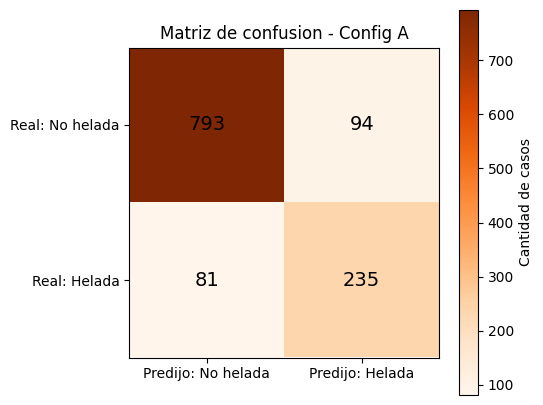

In [38]:
conf_matrix_a = (
    predicciones_log_simple
    .groupBy("hay_helada", "prediction")
    .count()
    .toPandas()
)

tabla_a = conf_matrix_a.pivot(index="hay_helada", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5, 5))
plt.imshow(tabla_a.values, cmap="Oranges")
plt.colorbar(label="Cantidad de casos")
plt.xticks([0, 1], ["Predijo: No helada", "Predijo: Helada"])
plt.yticks([0, 1], ["Real: No helada", "Real: Helada"])
for i in range(tabla_a.shape[0]):
    for j in range(tabla_a.shape[1]):
        plt.text(j, i, int(tabla_a.values[i, j]), ha="center", va="center", color="black", fontsize=14)
plt.title("Matriz de confusion - Config A")
plt.show()

## 8.4 Matriz de confusión del modelo ganador

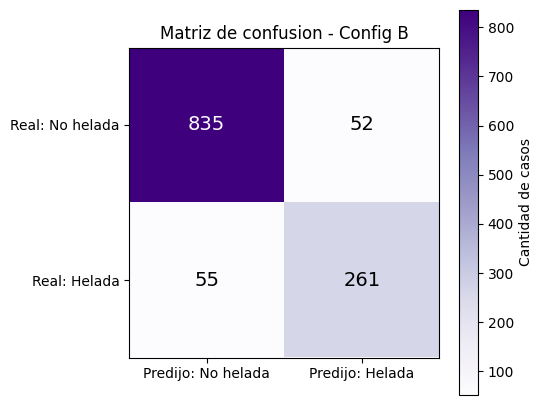

In [40]:
conf_matrix = (
    predicciones_log_enriquecido
    .groupBy("hay_helada", "prediction")
    .count()
    .toPandas()
)

tabla = conf_matrix.pivot(index="hay_helada", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5, 5))
plt.imshow(tabla.values, cmap="Purples")
plt.colorbar(label="Cantidad de casos")
plt.xticks([0, 1], ["Predijo: No helada", "Predijo: Helada"])
plt.yticks([0, 1], ["Real: No helada", "Real: Helada"])

maximo = tabla.values.max()
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        valor = tabla.values[i, j]
        color_texto = "white" if valor > maximo * 0.5 else "black"
        plt.text(j, i, int(valor), ha="center", va="center", color=color_texto, fontsize=14)

plt.title("Matriz de confusion - Config B")
plt.show()

## 9. Guardar el modelo ganador

In [25]:
RUTA_MODELO = "/opt/bigdata-u1/artifacts/modelo_heladas_config_b"

modelo_log_enriquecido.write().overwrite().save(RUTA_MODELO)

print(f"Modelo guardado en: {RUTA_MODELO}")

Modelo guardado en: /opt/bigdata-u1/artifacts/modelo_heladas_config_b
